In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import matplotlib.font_manager as fm

# 한글 폰트 설정
available_fonts = {f.name for f in fm.fontManager.ttflist}

for font_name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break

plt.rcParams['axes.unicode_minus'] = False

# describe(), 결측치 표, 상관계수 표를 보기 좋게 만들기 위한 기본 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
music_df = pd.read_csv('../01_data/raw/train.csv')
census_df = pd.read_csv('../01_data/raw/acs2015_census_tract_data.csv')

In [3]:
# location 오타 수정
music_df['location'] = music_df['location'].replace({
    'Nebrasksa': 'Nebraska'
})

In [4]:
# 원본 데이터 기본 점검
music_raw = music_df.copy()
census_raw = census_df.copy()

print(f"music_df shape: {music_df.shape}")
print(f"census_df shape: {census_df.shape}")

raw_summary_music = pd.DataFrame({
    'dtype': music_df.dtypes.astype(str),
    'missing_cnt': music_df.isna().sum(),
    'missing_ratio(%)': (music_df.isna().mean() * 100).round(2),
    'nunique': music_df.nunique(dropna=False)
}).sort_values(['missing_cnt', 'nunique'], ascending=[False, False])

display(raw_summary_music)

num_cols_music = music_df.select_dtypes(include=np.number).columns.tolist()
cat_cols_music = music_df.select_dtypes(exclude=np.number).columns.tolist()

print("수치형 컬럼:", num_cols_music)
print("범주형 컬럼:", cat_cols_music)

display(music_df[num_cols_music].describe().T)

print("\n[churned 분포]")
display(
    music_df['churned']
    .value_counts(dropna=False)
    .rename_axis('churned')
    .reset_index(name='count')
    .assign(ratio=lambda x: (x['count'] / len(music_df) * 100).round(2))
)

eda_cat_cols = ['location', 'subscription_type', 'payment_plan', 'payment_method', 'customer_service_inquiries']
for col in eda_cat_cols:
    print(f"\n[{col}]")
    display(
        music_df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name='count')
        .assign(ratio=lambda x: (x['count'] / len(music_df) * 100).round(2))
        .head(20)
    )

music_df shape: (125000, 20)
census_df shape: (74001, 37)


,dtype,missing_cnt,missing_ratio(%),nunique
customer_id,int64,0,0.0000,125000
weekly_hours,float64,0,0.0000,125000
average_session_length,float64,0,0.0000,124996
song_skip_rate,float64,0,0.0000,124995
signup_date,int64,0,0.0000,2922
weekly_songs_played,int64,0,0.0000,497
weekly_unique_songs,int64,0,0.0000,297
num_platform_friends,int64,0,0.0000,200
num_playlists_created,int64,0,0.0000,100
age,int64,0,0.0000,62


수치형 컬럼: ['customer_id', 'age', 'num_subscription_pauses', 'signup_date', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'churned']
범주형 컬럼: ['location', 'subscription_type', 'payment_plan', 'payment_method', 'customer_service_inquiries']


,count,mean,std,min,25%,50%,75%,max
customer_id,"125,000.0000","62,500.5000","36,084.5362",1.0000,"31,250.7500","62,500.5000","93,750.2500","125,000.0000"
age,"125,000.0000",48.4141,17.9010,18.0000,33.0000,48.0000,64.0000,79.0000
num_subscription_pauses,"125,000.0000",1.9911,1.4172,0.0000,1.0000,2.0000,3.0000,4.0000
signup_date,"125,000.0000","-1,460.6789",844.1329,"-2,922.0000","-2,190.0000","-1,462.0000",-728.0000,-1.0000
weekly_hours,"125,000.0000",25.0370,14.4475,0.0001,12.4727,25.1167,37.5703,49.9999
average_session_length,"125,000.0000",60.4217,34.3838,1.0005,30.6442,60.3410,90.2342,119.9965
song_skip_rate,"125,000.0000",0.5008,0.2887,0.0000,0.2510,0.5012,0.7511,1.0000
weekly_songs_played,"125,000.0000",250.8239,143.3276,3.0000,127.0000,251.0000,375.0000,499.0000
weekly_unique_songs,"125,000.0000",150.7833,85.7950,3.0000,76.0000,150.0000,225.0000,299.0000
num_favorite_artists,"125,000.0000",24.4999,14.4460,0.0000,12.0000,25.0000,37.0000,49.0000



[churned 분포]


...

,payment_plan,count,ratio
0,Monthly,62562,50.0500
1,Yearly,62438,49.9500



[payment_method]


,payment_method,count,ratio
0,Debit Card,31292,25.0300
1,Paypal,31282,25.0300
2,Credit Card,31213,24.9700
3,Apple Pay,31213,24.9700



[customer_service_inquiries]


,customer_service_inquiries,count,ratio
0,Low,41873,33.5000
1,High,41583,33.2700
2,Medium,41544,33.2400


In [5]:
# customer_id 삭제
if 'customer_id' in music_df.columns:
    music_df = music_df.drop('customer_id', axis=1)

In [6]:
income_missing_before = census_df['Income'].isna().sum()
zero_totalpop_cnt = (census_df['TotalPop'] == 0).sum()

# Census 데이터 전처리
census_df['Income'] = census_df.groupby('State')['Income'].transform(lambda x: x.fillna(x.median()))

# State별 집계
state_stats = census_df.groupby('State').agg({
    'TotalPop': 'sum',
    'Income': 'mean'
}).reset_index()

# 컬럼명 변경
state_stats.columns = ['State', 'State_TotalPop', 'State_AvgIncome']

print(f"Income 결측치(전): {income_missing_before}")
print(f"Income 결측치(후): {census_df['Income'].isna().sum()}")
print(f"TotalPop == 0 개수: {zero_totalpop_cnt}")

print("\n[state_stats 기본 통계]")
display(state_stats.describe().T)

music_states = set(music_df['location'].dropna().unique())
census_states = set(state_stats['State'].dropna().unique())

only_music = sorted(music_states - census_states)
only_census = sorted(census_states - music_states)

print("\nmusic_df에만 있는 location 값")
print(only_music)

print("\nstate_stats에만 있는 State 값")
print(only_census)

Income 결측치(전): 1100
Income 결측치(후): 0
TotalPop == 0 개수: 690

[state_stats 기본 통계]


,count,mean,std,min,25%,50%,75%,max
State_TotalPop,52.0000,"6,155,732.5769","6,992,998.8097","579,679.0000","1,792,701.7500","4,168,293.0000","6,775,555.5000","38,421,464.0000"
State_AvgIncome,52.0000,"55,919.9565","11,361.0298","20,513.9058","48,477.0198","54,188.0266","63,634.0427","78,657.1771"



music_df에만 있는 location 값
[]

state_stats에만 있는 State 값
['Alaska', 'Arizona', 'Arkansas', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Hawaii', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nevada', 'New Hampshire', 'New Mexico', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Dakota', 'Tennessee', 'Texas', 'Wyoming']


In [7]:
# 데이터 병합 + 병합 상태 점검
final_df = pd.merge(
    music_df,
    state_stats,
    left_on='location',
    right_on='State',
    how='left',
    indicator=True
)

print("병합 결과 요약")
display(
    final_df['_merge']
    .value_counts(dropna=False)
    .rename_axis('_merge')
    .reset_index(name='count')
    .assign(ratio=lambda x: (x['count'] / len(final_df) * 100).round(2))
)

print("\n매칭 실패 location 상위")
display(
    final_df.loc[final_df['_merge'] != 'both', 'location']
    .value_counts(dropna=False)
    .rename_axis('location')
    .reset_index(name='count')
    .head(20)
)

병합 결과 요약


,_merge,count,ratio
0,both,125000,100.0000
1,left_only,0,0.0000
2,right_only,0,0.0000



매칭 실패 location 상위


,location,count


In [8]:
# 병합 확인용 컬럼, 사용하지 않을 지역 변수 제거
final_df = final_df.drop(['State', '_merge', 'State_TotalPop'], axis=1, errors='ignore')

In [9]:
# 수치 데이터 보정
final_df['average_session_length'] = final_df['average_session_length'] / 60
final_df['weekly_unique_songs'] = np.where(
    final_df['weekly_unique_songs'] > final_df['weekly_songs_played'],
    final_df['weekly_songs_played'],
    final_df['weekly_unique_songs']
)

final_df['tenure_days'] = final_df['signup_date'].abs()
final_df = final_df.drop('signup_date', axis=1)

In [10]:
# 전처리 논리 점검
logic_check = pd.Series({
    'weekly_unique_songs > weekly_songs_played': int((final_df['weekly_unique_songs'] > final_df['weekly_songs_played']).sum()),
    'average_session_length <= 0': int((final_df['average_session_length'] <= 0).sum()),
    'song_skip_rate < 0 or > 1': int(((final_df['song_skip_rate'] < 0) | (final_df['song_skip_rate'] > 1)).sum()),
    'weekly_hours < 0': int((final_df['weekly_hours'] < 0).sum()),
    'tenure_days < 0': int((final_df['tenure_days'] < 0).sum())
}, name='count')

display(logic_check.to_frame())

print("\ntenure_days 요약")
display(final_df['tenure_days'].describe().to_frame().T)

# 가설 EDA용 원본 형태 백업
model_df = final_df.copy()

,count
weekly_unique_songs > weekly_songs_played,0
average_session_length <= 0,0
song_skip_rate < 0 or > 1,0
weekly_hours < 0,0
tenure_days < 0,0



tenure_days 요약


,count,mean,std,min,25%,50%,75%,max
tenure_days,"125,000.0000","1,460.6789",844.1329,1.0000,728.0000,"1,462.0000","2,190.0000","2,922.0000"


In [11]:
# 범주형 변수 유지, EDA용 데이터셋 기준으로 분석
cat_cols = model_df.select_dtypes(exclude=np.number).columns.tolist()
num_cols = model_df.select_dtypes(include=np.number).columns.tolist()

print("범주형 컬럼:")
print(cat_cols)

print("\n수치형 컬럼:")
print(num_cols)

범주형 컬럼:
['location', 'subscription_type', 'payment_plan', 'payment_method', 'customer_service_inquiries']

수치형 컬럼:
['age', 'num_subscription_pauses', 'weekly_hours', 'average_session_length', 'song_skip_rate', 'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists', 'num_platform_friends', 'num_playlists_created', 'num_shared_playlists', 'notifications_clicked', 'churned', 'State_AvgIncome', 'tenure_days']


In [12]:
# 수치형 이상치(IQR) 요약
# 연속형/실수형 중심 컬럼만 선택
iqr_cols = [
    'age', 'tenure_days', 'weekly_hours', 'average_session_length', 'song_skip_rate',
    'weekly_songs_played', 'weekly_unique_songs', 'num_favorite_artists',
    'num_platform_friends', 'num_playlists_created', 'num_shared_playlists',
    'notifications_clicked', 'State_AvgIncome'
]

outlier_rows = []
for col in iqr_cols:
    q1 = model_df[col].quantile(0.25)
    q3 = model_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_cnt = ((model_df[col] < lower) | (model_df[col] > upper)).sum()

    outlier_rows.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower': lower,
        'upper': upper,
        'outlier_cnt': int(out_cnt),
        'outlier_ratio(%)': round(out_cnt / len(model_df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_ratio(%)', ascending=False)
display(outlier_summary.head(20))

# 상관분석: 수치형 변수만 추출
corr_df = model_df.select_dtypes(include=np.number).copy()

corr_matrix = corr_df.corr(numeric_only=True)

print("\n수치형 변수 간 상관계수 행렬")
display(corr_matrix)

corr_with_target = (
    corr_matrix['churned']
    .drop('churned')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("\nchurned와의 상관계수 상위 변수")
display(corr_with_target.to_frame('corr_with_churned'))

,column,q1,q3,iqr,lower,upper,outlier_cnt,outlier_ratio(%)
0,age,33.0000,64.0000,31.0000,-13.5000,110.5000,0,0.0000
1,tenure_days,728.0000,"2,190.0000","1,462.0000","-1,465.0000","4,383.0000",0,0.0000
2,weekly_hours,12.4727,37.5703,25.0977,-25.1738,75.2168,0,0.0000
3,average_session_length,0.5107,1.5039,0.9932,-0.9790,2.9937,0,0.0000
4,song_skip_rate,0.2510,0.7511,0.5001,-0.4992,1.5013,0,0.0000
5,weekly_songs_played,127.0000,375.0000,248.0000,-245.0000,747.0000,0,0.0000
6,weekly_unique_songs,52.0000,182.0000,130.0000,-143.0000,377.0000,0,0.0000
7,num_favorite_artists,12.0000,37.0000,25.0000,-25.5000,74.5000,0,0.0000
8,num_platform_friends,50.0000,150.0000,100.0000,-100.0000,300.0000,0,0.0000
9,num_playlists_created,24.0000,75.0000,51.0000,-52.5000,151.5000,0,0.0000



수치형 변수 간 상관계수 행렬


,age,num_subscription_pauses,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome,tenure_days
age,1.0000,-0.0003,0.0018,0.0006,0.0019,-0.0017,-0.0035,0.0022,0.0010,0.0034,0.0014,-0.0001,0.0487,-0.0002,0.0016
num_subscription_pauses,-0.0003,1.0000,0.0038,0.0011,0.0063,-0.0008,-0.0033,-0.0000,-0.0009,0.0005,0.0004,0.0039,0.1830,-0.0002,-0.0031
weekly_hours,0.0018,0.0038,1.0000,0.0012,0.0057,-0.0016,0.0010,-0.0051,-0.0071,-0.0006,-0.0015,-0.0040,-0.3025,0.0016,0.0004
average_session_length,0.0006,0.0011,0.0012,1.0000,-0.0041,-0.0004,-0.0034,0.0015,-0.0001,0.0057,-0.0049,0.0002,-0.0065,-0.0015,-0.0044
song_skip_rate,0.0019,0.0063,0.0057,-0.0041,1.0000,-0.0031,0.0002,0.0016,0.0025,-0.0021,0.0016,0.0012,0.1602,0.0007,0.0025
weekly_songs_played,-0.0017,-0.0008,-0.0016,-0.0004,-0.0031,1.0000,0.4468,0.0047,0.0031,-0.0017,0.0017,-0.0026,0.0009,-0.0018,-0.0026
weekly_unique_songs,-0.0035,-0.0033,0.0010,-0.0034,0.0002,0.4468,1.0000,0.0035,-0.0027,-0.0018,-0.0001,-0.0019,0.0138,-0.0028,0.0018
num_favorite_artists,0.0022,-0.0000,-0.0051,0.0015,0.0016,0.0047,0.0035,1.0000,-0.0012,0.0038,-0.0003,-0.0001,-0.0054,0.0000,-0.0019
num_platform_friends,0.0010,-0.0009,-0.0071,-0.0001,0.0025,0.0031,-0.0027,-0.0012,1.0000,-0.0014,-0.0012,-0.0034,-0.0030,0.0028,-0.0003
num_playlists_created,0.0034,0.0005,-0.0006,0.0057,-0.0021,-0.0017,-0.0018,0.0038,-0.0014,1.0000,-0.0004,0.0006,-0.0022,-0.0011,0.0020



churned와의 상관계수 상위 변수


,corr_with_churned
weekly_hours,-0.3025
num_subscription_pauses,0.1830
song_skip_rate,0.1602
age,0.0487
notifications_clicked,-0.0424
weekly_unique_songs,0.0138
average_session_length,-0.0065
num_favorite_artists,-0.0054
num_shared_playlists,0.0038
num_platform_friends,-0.0030


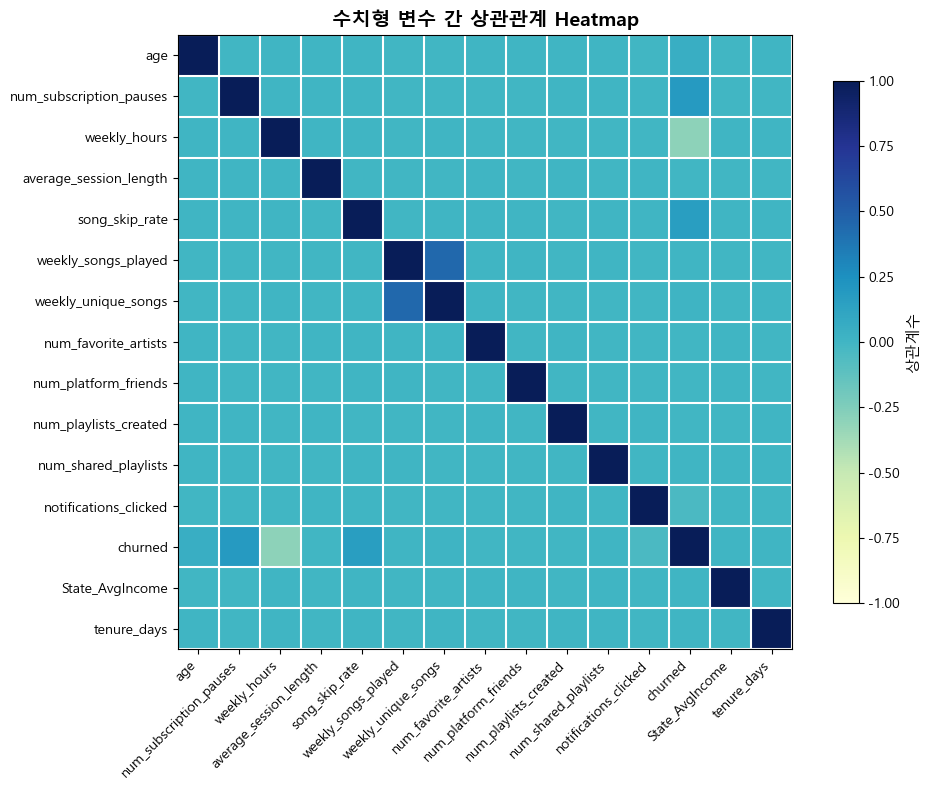

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 수치형 변수만 추출
corr_df = model_df.select_dtypes(include=np.number).copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    corr_matrix,
    cmap='YlGnBu',   # 부드러운 블루-그린 계열
    vmin=-1,
    vmax=1
)

# 축 라벨
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index, fontsize=10)

# 격자선 추가
ax.set_xticks(np.arange(-.5, len(corr_matrix.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(corr_matrix.index), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('상관계수', fontsize=11)

ax.set_title('수치형 변수 간 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

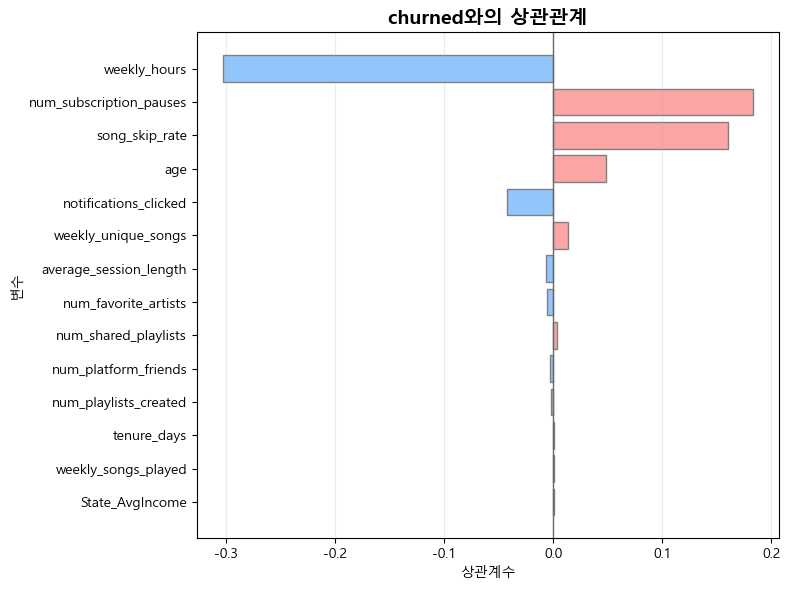

In [14]:
# churned와의 상관계수만 따로 보기
corr_with_target = (
    corr_matrix['churned']
    .drop('churned')
    .sort_values(key=lambda s: s.abs(), ascending=True)
)

plt.figure(figsize=(8, 6))

colors = ['#93c5fd' if x < 0 else '#fca5a5' for x in corr_with_target.values]

plt.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='gray')
plt.axvline(0, color='dimgray', linewidth=1)

plt.xlabel('상관계수')
plt.ylabel('변수')
plt.title('churned와의 상관관계', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

In [15]:
from scipy.stats import chi2_contingency

cat_cols = model_df.select_dtypes(include=['object', 'string']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'churned']

result_rows = []

for col in cat_cols:
    cont_table = pd.crosstab(model_df[col], model_df['churned'])
    chi2, p, dof, expected = chi2_contingency(cont_table)

    result_rows.append({
        'variable': col,
        'chi2_stat': chi2,
        'p_value': p,
        'n_categories': model_df[col].nunique()
    })

chi2_result = pd.DataFrame(result_rows).sort_values('p_value')
display(chi2_result)

,variable,chi2_stat,p_value,n_categories
1,subscription_type,"17,626.1546",0.0000,4
4,customer_service_inquiries,"17,225.8471",0.0000,3
3,payment_method,8.1493,0.0430,4
2,payment_plan,0.2224,0.6372,2
0,location,8.0614,0.9777,19


In [16]:
def plot_categorical_churn_rate(df, col, target='churned'):
    summary = (
        df.groupby(col, as_index=False)
        .agg(
            total_users=(target, 'size'),
            churn_users=(target, 'sum'),
            churn_rate=(target, 'mean')
        )
        .sort_values('churn_rate', ascending=False)
    )
    summary['churn_rate_pct'] = (summary['churn_rate'] * 100).round(2)

    display(summary)

    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        summary[col].astype(str),
        summary['churn_rate_pct'],
        color='#fbcfe8',
        edgecolor='gray'
    )

    overall_rate = df[target].mean() * 100
    plt.axhline(
        overall_rate,
        color='dimgray',
        linestyle='--',
        linewidth=1.5,
        label=f'전체 평균 이탈률: {overall_rate:.1f}%'
    )

    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            y + 0.4,
            f'{y:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f'{col}별 이탈률', fontsize=14, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('이탈률 (%)')
    plt.xticks(rotation=20)
    plt.legend(frameon=False)
    plt.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

,subscription_type,total_users,churn_users,churn_rate,churn_rate_pct
1,Free,31269,24830,0.7941,79.4100
3,Student,31305,17967,0.5739,57.3900
0,Family,31072,10745,0.3458,34.5800
2,Premium,31354,10632,0.3391,33.9100


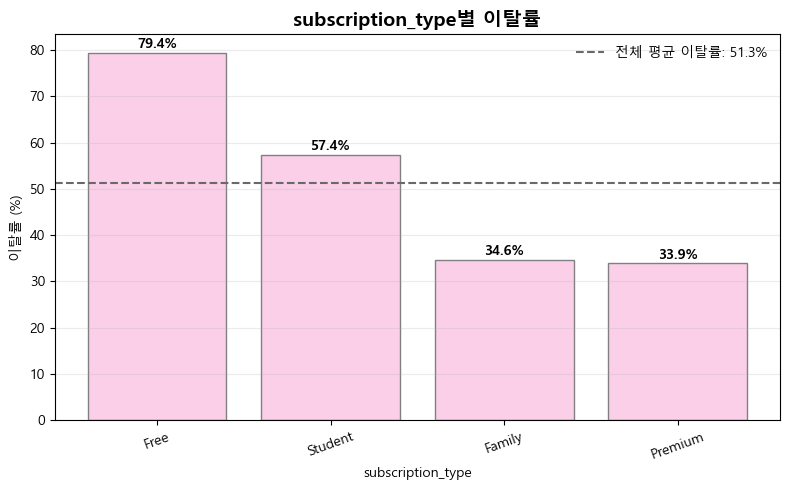

,payment_plan,total_users,churn_users,churn_rate,churn_rate_pct
0,Monthly,62562,32161,0.5141,51.4100
1,Yearly,62438,32013,0.5127,51.2700


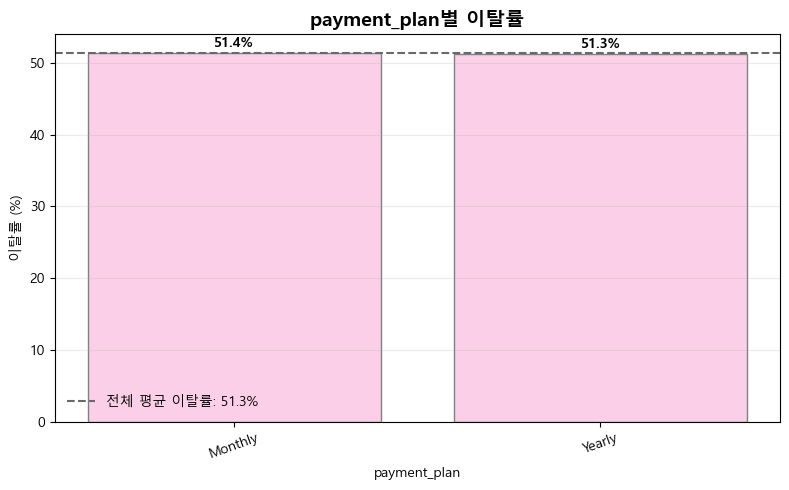

,payment_method,total_users,churn_users,churn_rate,churn_rate_pct
0,Apple Pay,31213,16198,0.5190,51.9000
2,Debit Card,31292,16115,0.5150,51.5000
3,Paypal,31282,16003,0.5116,51.1600
1,Credit Card,31213,15858,0.5081,50.8100


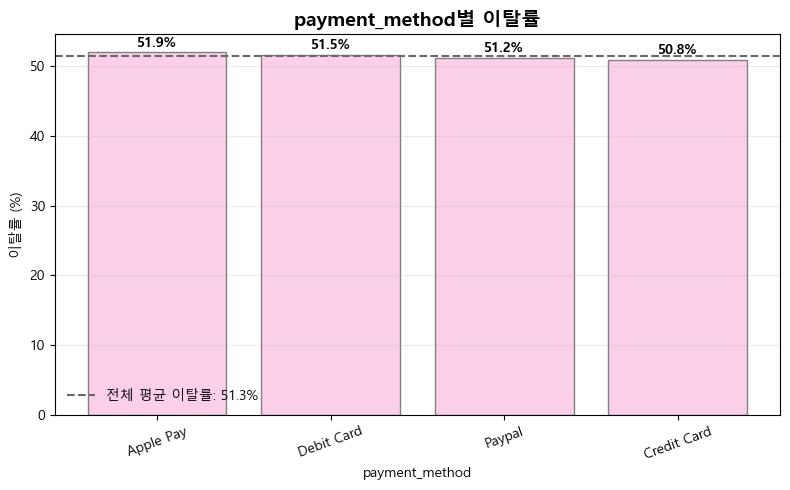

,customer_service_inquiries,total_users,churn_users,churn_rate,churn_rate_pct
0,High,41583,30910,0.7433,74.3300
2,Medium,41544,21153,0.5092,50.9200
1,Low,41873,12111,0.2892,28.9200


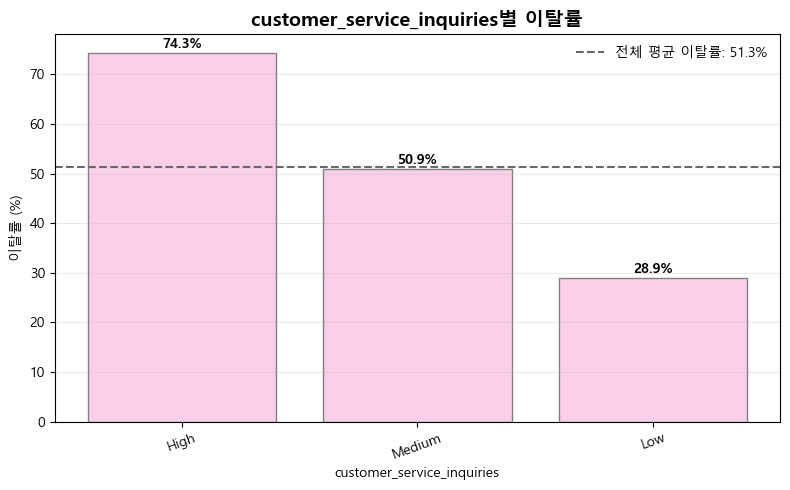

,location,total_users,churn_users,churn_rate,churn_rate_pct
1,Georgia,6705,3497,0.5216,52.1600
9,Washington,6638,3434,0.5173,51.7300
4,New Jersey,6634,3429,0.5169,51.6900
6,North Dakota,6577,3394,0.5160,51.6000
8,Vermont,6676,3442,0.5156,51.5600
7,Utah,6577,3386,0.5148,51.4800
0,California,6665,3425,0.5139,51.3900
5,North Carolina,6583,3380,0.5134,51.3400
3,Nebraska,6601,3386,0.5130,51.3000
2,Idaho,6697,3424,0.5113,51.1300


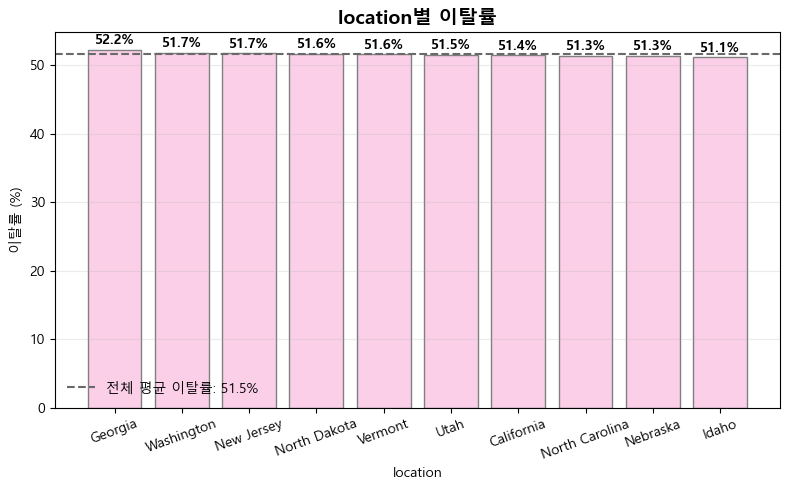

In [17]:
# 범주형 변수 시각화
plot_categorical_churn_rate(model_df, 'subscription_type')
plot_categorical_churn_rate(model_df, 'payment_plan')
plot_categorical_churn_rate(model_df, 'payment_method')
plot_categorical_churn_rate(model_df, 'customer_service_inquiries')

# location은 top 10만
top_states = model_df['location'].value_counts().head(10).index
plot_df = model_df[model_df['location'].isin(top_states)]

plot_categorical_churn_rate(plot_df, 'location')

In [18]:
def plot_categorical_stacked_bar(df, col, target='churned'):
    ratio_df = pd.crosstab(df[col], df[target], normalize='index') * 100
    ratio_df.columns = ['유지(0)', '이탈(1)']

    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ['#dbeafe', '#fecaca']  # 유지: 연파랑, 이탈: 연빨강
    bottom = np.zeros(len(ratio_df))

    for label, color in zip(ratio_df.columns, colors):
        bars = ax.bar(
            ratio_df.index.astype(str),
            ratio_df[label],
            bottom=bottom,
            label=label,
            color=color,
            edgecolor='white',
            linewidth=1.5
        )

        for i, val in enumerate(ratio_df[label]):
            if val >= 8:
                ax.text(
                    i,
                    bottom[i] + val / 2,
                    f'{val:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold'
                )

        bottom += ratio_df[label].values

    ax.set_title(f'{col}별 churn 구성비', fontsize=14, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('비율 (%)')
    ax.set_ylim(0, 100)
    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.25)

    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

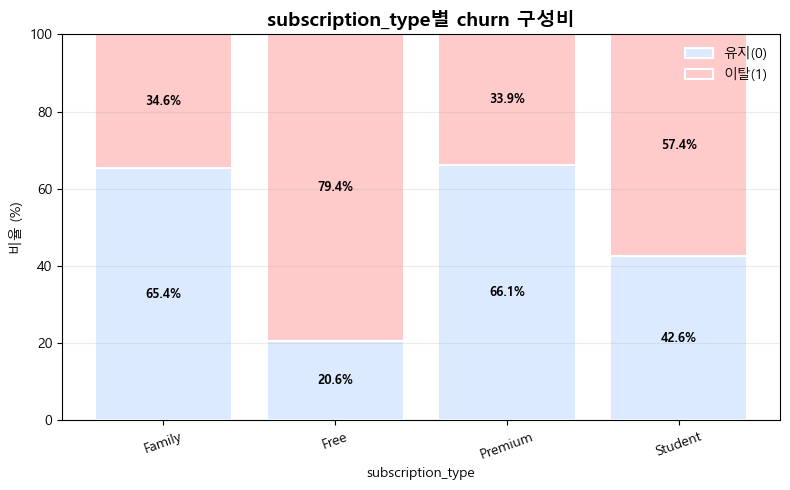

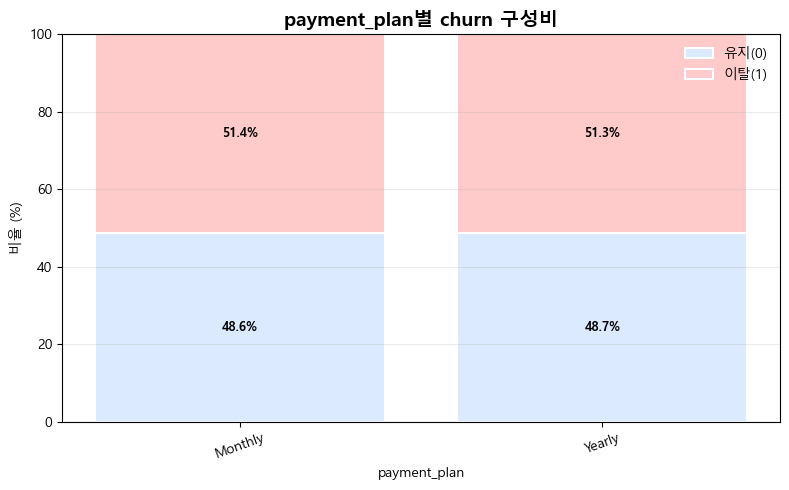

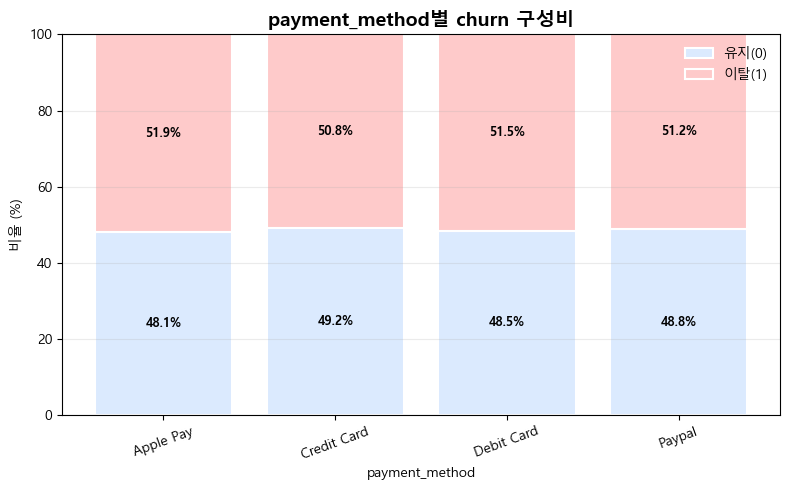

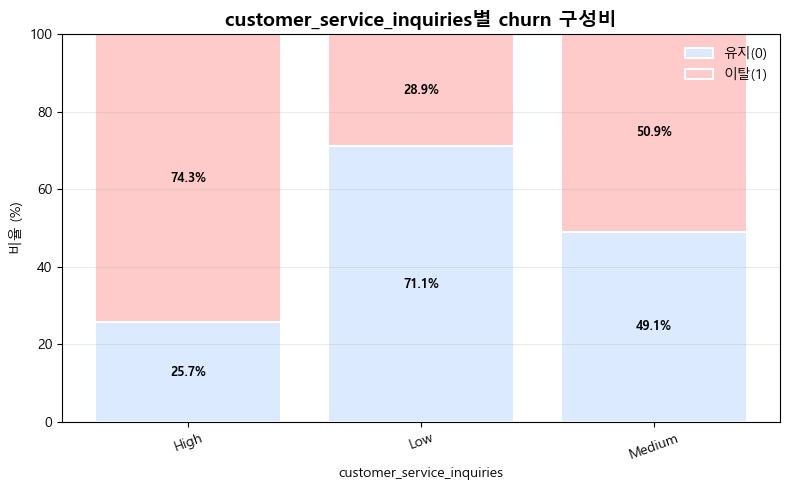

In [19]:
plot_categorical_stacked_bar(model_df, 'subscription_type')
plot_categorical_stacked_bar(model_df, 'payment_plan')
plot_categorical_stacked_bar(model_df, 'payment_method')
plot_categorical_stacked_bar(model_df, 'customer_service_inquiries')

In [20]:
# EDA 데이터 결과 확인
print(f"EDA 데이터 형태: {model_df.shape}")
display(model_df.head())

print("\nEDA 데이터 수치형 기본 통계")
display(model_df.describe(include=[np.number]).T)

print("\nEDA 데이터 범주형 기본 통계")
display(model_df.describe(include=['object', 'string']).T)

print("\nEDA 데이터 결측치 요약")
missing_summary = pd.DataFrame({
    'missing_cnt': model_df.isna().sum(),
    'missing_ratio(%)': (model_df.isna().mean() * 100).round(2),
    'nunique': model_df.nunique(dropna=False)
}).sort_values(['missing_cnt', 'nunique'], ascending=[False, False])

display(missing_summary)

print("\n중복 행 수:", model_df.duplicated().sum())

print("\n타깃(churned) 분포")
display(
    model_df['churned']
    .value_counts(dropna=False)
    .rename_axis('churned')
    .reset_index(name='count')
    .assign(ratio=lambda x: (x['count'] / len(model_df) * 100).round(2))
)

constant_cols = [col for col in model_df.columns if model_df[col].nunique(dropna=False) <= 1]
print("\n상수 컬럼:", constant_cols)

EDA 데이터 형태: (125000, 20)


,age,location,subscription_type,payment_plan,num_subscription_pauses,payment_method,customer_service_inquiries,weekly_hours,average_session_length,song_skip_rate,weekly_songs_played,weekly_unique_songs,num_favorite_artists,num_platform_friends,num_playlists_created,num_shared_playlists,notifications_clicked,churned,State_AvgIncome,tenure_days
0,32,Montana,Free,Yearly,2,Paypal,Medium,22.3914,1.7566,0.1769,169,109,18,32,52,35,46,0,"47,631.1568",1606
1,64,New Jersey,Free,Monthly,3,Paypal,Low,29.2942,0.8750,0.9818,55,55,44,33,12,25,37,1,"76,533.2965",2897
2,51,Washington,Premium,Yearly,2,Credit Card,High,15.4003,0.4117,0.0484,244,117,20,129,50,28,38,0,"64,452.0583",348
3,63,California,Family,Yearly,4,Apple Pay,Medium,22.8421,1.3933,0.0357,442,252,47,120,55,17,24,0,"67,180.1817",2894
4,54,Washington,Family,Monthly,3,Paypal,High,23.1512,0.8763,0.0397,243,230,41,66,40,32,47,0,"64,452.0583",92



EDA 데이터 수치형 기본 통계


,count,mean,std,min,25%,50%,75%,max
age,"125,000.0000",48.4141,17.9010,18.0000,33.0000,48.0000,64.0000,79.0000
num_subscription_pauses,"125,000.0000",1.9911,1.4172,0.0000,1.0000,2.0000,3.0000,4.0000
weekly_hours,"125,000.0000",25.0370,14.4475,0.0001,12.4727,25.1167,37.5703,49.9999
average_session_length,"125,000.0000",1.0070,0.5731,0.0167,0.5107,1.0057,1.5039,1.9999
song_skip_rate,"125,000.0000",0.5008,0.2887,0.0000,0.2510,0.5012,0.7511,1.0000
weekly_songs_played,"125,000.0000",250.8239,143.3276,3.0000,127.0000,251.0000,375.0000,499.0000
weekly_unique_songs,"125,000.0000",121.2659,80.3908,3.0000,52.0000,110.0000,182.0000,299.0000
num_favorite_artists,"125,000.0000",24.4999,14.4460,0.0000,12.0000,25.0000,37.0000,49.0000
num_platform_friends,"125,000.0000",99.7132,57.6814,0.0000,50.0000,100.0000,150.0000,199.0000
num_playlists_created,"125,000.0000",49.4580,28.9353,0.0000,24.0000,49.0000,75.0000,99.0000



EDA 데이터 범주형 기본 통계


...


EDA 데이터 결측치 요약


,missing_cnt,missing_ratio(%),nunique
weekly_hours,0,0.0000,125000
average_session_length,0,0.0000,124996
song_skip_rate,0,0.0000,124995
tenure_days,0,0.0000,2922
weekly_songs_played,0,0.0000,497
weekly_unique_songs,0,0.0000,297
num_platform_friends,0,0.0000,200
num_playlists_created,0,0.0000,100
age,0,0.0000,62
num_favorite_artists,0,0.0000,50



중복 행 수: 0

타깃(churned) 분포


,churned,count,ratio
0,1,64174,51.3400
1,0,60826,48.6600



상수 컬럼: []


In [21]:
from pathlib import Path

# 저장 경로 설정
BASE_DIR = Path().resolve().parent
save_path = BASE_DIR / "01_data" / "processed" / "model_df.csv"

# CSV 저장
model_df.to_csv(save_path, index=False)

print(f"파일 저장 완료: {save_path}")

파일 저장 완료: C:\Users\Playdata\Documents\JANI\01_data\processed\model_df.csv
